In [ ]:
# %% =========================================================
# cell 1. imports and device setup
# purpose:
# load required libraries and choose the best available device
# for comparing active and passive learning models
# ============================================================

import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [ ]:
# %% =========================================================
# cell 2. mount drive and define paths
# purpose:
# point to the new combined dataset and the saved model/history files
# stored in Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

project_dir = Path("/content/drive/MyDrive/ASR_Project")
data_dir = project_dir / "DATA" / "combined_dataset2"

images_dir = data_dir / "images"
labels_dir = data_dir / "masks"
index_csv_path = data_dir / "dataset_index.csv"

active_model_path = project_dir / "active_model_final.pt"
passive_model_path = project_dir / "passive_model_final.pt"

active_history_path = project_dir / "active_history.csv"
passive_history_path = project_dir / "passive_history.csv"

print("images_dir exists:", images_dir.exists())
print("labels_dir exists:", labels_dir.exists())
print("index csv exists:", index_csv_path.exists())
print("active_model_path exists:", active_model_path.exists())
print("passive_model_path exists:", passive_model_path.exists())
print("active_history_path exists:", active_history_path.exists())
print("passive_history_path exists:", passive_history_path.exists())

Mounted at /content/drive
images_dir exists: True
labels_dir exists: True
index csv exists: True
active_model_path exists: True
passive_model_path exists: True
active_history_path exists: True
passive_history_path exists: True


In [ ]:
# %% =========================================================
# cell 3. read dataset index csv
# purpose:
# read the dataset index and use it directly to define the test split
# ============================================================

index_df = pd.read_csv(index_csv_path)

print("index_df shape:", index_df.shape)
print("columns:", index_df.columns.tolist())
print(index_df.head())
print("\nsplit counts:")
print(index_df["split"].value_counts())

index_df shape: (966, 4)
columns: ['image_path', 'mask_path', 'source', 'split']
                                          image_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/combin...   
1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
3  /content/drive/MyDrive/ASR_Project/DATA/combin...   
4  /content/drive/MyDrive/ASR_Project/DATA/combin...   

                                           mask_path   source  split  
0  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
1  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
2  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
3  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
4  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  

split counts:
split
train    676
test     146
val      144
Name: count, dtype: int64


In [ ]:
# %% =========================================================
# cell 4. build sample table, force stable ordering, and extract test split
# purpose:
# create a clean sample table, force a stable order across notebooks,
# and keep only the test examples for model comparison
# ============================================================

samples_df = index_df.copy()
samples_df["image_id"] = samples_df["image_path"].apply(lambda x: Path(x).stem)
samples_df = samples_df[["image_id", "image_path", "mask_path", "source", "split"]]

# force a stable order so dataset indices mean the same thing
samples_df = samples_df.sort_values(["source", "image_id"]).reset_index(drop=True)

print("samples_df shape:", samples_df.shape)
print(samples_df.head())

print("\nunique split values:")
print(samples_df["split"].unique())

train_df = samples_df[samples_df["split"] == "train"].reset_index(drop=True)
val_df = samples_df[samples_df["split"] == "val"].reset_index(drop=True)
test_df = samples_df[samples_df["split"] == "test"].reset_index(drop=True)

print("\ntrain_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)
print("\nfirst test rows:")
print(test_df[["image_id", "source"]].head(10))


samples_df shape: (966, 5)
         image_id                                         image_path  \
0  bbbc006_a01_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
1  bbbc006_a01_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
2  bbbc006_a02_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
3  bbbc006_a02_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
4  bbbc006_a03_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   

                                           mask_path   source  split  
0  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006    val  
1  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
2  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  
3  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006    val  
4  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  train  

unique split values:
['val' 'train' 'test']

train_df shape: (676, 5)
val_df shape: (144, 5)
test_df shape: (146,

In [ ]:
# %% =========================================================
# cell 5. dataset class for comparison
# purpose:
# load image and mask pairs from the combined dataset while:
# - preserving 16-bit fluorescence intensity when present
# - forcing all images to a single channel
# - forcing all masks to binary single-channel
# - making every returned tensor the same shape
# ============================================================

class SegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=(256, 256)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        # -------------------------
        # load image robustly
        # -------------------------
        image = np.array(Image.open(row["image_path"]))

        # if image has multiple channels, reduce to one channel
        if image.ndim == 3:
            image = image[..., 0]

        image = image.astype(np.float32)

        # percentile normalization for fluorescence images
        lo = np.percentile(image, 1)
        hi = np.percentile(image, 99)

        if hi > lo:
            image = np.clip((image - lo) / (hi - lo), 0, 1)
        else:
            image = np.zeros_like(image, dtype=np.float32)

        # resize image after normalization
        image_pil = Image.fromarray((image * 255).astype(np.uint8))
        image = np.array(
            image_pil.resize(self.image_size, Image.BILINEAR),
            dtype=np.float32
        ) / 255.0

        # -------------------------
        # load mask robustly
        # -------------------------
        mask = np.array(Image.open(row["mask_path"]))

        # if mask has multiple channels, reduce to one channel
        if mask.ndim == 3:
            mask = mask[..., 0]

        mask = mask.astype(np.float32)

        # convert mask to binary
        mask = (mask > 0).astype(np.float32)

        # resize mask with nearest-neighbor
        mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
        mask = np.array(
            mask_pil.resize(self.image_size, Image.NEAREST),
            dtype=np.float32
        )
        mask = (mask > 0).astype(np.float32)

        # -------------------------
        # add channel dimension
        # -------------------------
        image = np.expand_dims(image, axis=0)   # [1, H, W]
        mask = np.expand_dims(mask, axis=0)     # [1, H, W]

        return {
            "image": torch.tensor(image, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "image_id": row["image_id"],
            "source": row["source"],
            "split": row["split"],
            "dataset_index": idx
        }

In [ ]:
# %% =========================================================
# cell 6. create test dataset
# purpose:
# instantiate the test dataset used for active vs passive comparison
# ============================================================

test_dataset = SegmentationDataset(test_df, image_size=(256, 256))

print("test dataset size:", len(test_dataset))

test dataset size: 146


image tensor shape: torch.Size([1, 256, 256])
mask tensor shape: torch.Size([1, 256, 256])
image id: bbbc006_a04_s1
processed image min/max: 0.0 1.0
processed mask unique values: tensor([0., 1.])


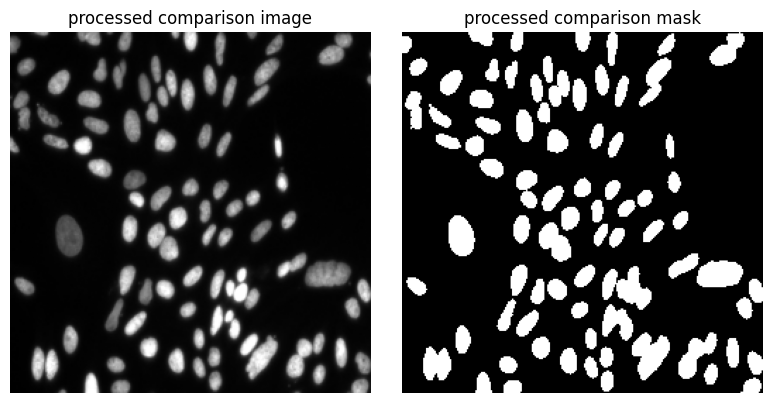

In [ ]:
# %% =========================================================
# qc cell. inspect one processed comparison sample
# purpose:
# verify that the comparison notebook loads test images correctly
# ============================================================

sample_item = test_dataset[0]

print("image tensor shape:", sample_item["image"].shape)
print("mask tensor shape:", sample_item["mask"].shape)
print("image id:", sample_item["image_id"])
print("processed image min/max:", sample_item["image"].min().item(), sample_item["image"].max().item())
print("processed mask unique values:", torch.unique(sample_item["mask"]))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_item["image"].squeeze().numpy(), cmap="gray")
plt.title("processed comparison image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_item["mask"].squeeze().numpy(), cmap="gray")
plt.title("processed comparison mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# %% =========================================================
# qc cell. inspect image and mask dimensionality
# purpose:
# find files that are not simple 2D grayscale images
# ============================================================

rows = []

for i in range(len(samples_df)):
    image = np.array(Image.open(samples_df.iloc[i]["image_path"]))
    mask = np.array(Image.open(samples_df.iloc[i]["mask_path"]))

    rows.append({
        "idx": i,
        "image_id": samples_df.iloc[i]["image_id"],
        "image_shape": image.shape,
        "mask_shape": mask.shape,
        "image_ndim": image.ndim,
        "mask_ndim": mask.ndim
    })

shape_df = pd.DataFrame(rows)

print("images with ndim != 2:")
print(shape_df[shape_df["image_ndim"] != 2].head(20))

print("\nmasks with ndim != 2:")
print(shape_df[shape_df["mask_ndim"] != 2].head(20))

images with ndim != 2:
Empty DataFrame
Columns: [idx, image_id, image_shape, mask_shape, image_ndim, mask_ndim]
Index: []

masks with ndim != 2:
     idx           image_id image_shape     mask_shape  image_ndim  mask_ndim
768  768  bbbc039_a02_s1_w1  (520, 696)  (520, 696, 4)           2          3
769  769  bbbc039_a06_s6_w1  (520, 696)  (520, 696, 4)           2          3
770  770  bbbc039_a09_s1_w1  (520, 696)  (520, 696, 4)           2          3
771  771  bbbc039_a12_s7_w1  (520, 696)  (520, 696, 4)           2          3
772  772  bbbc039_a15_s5_w1  (520, 696)  (520, 696, 4)           2          3
773  773  bbbc039_a16_s2_w1  (520, 696)  (520, 696, 4)           2          3
774  774  bbbc039_a16_s3_w1  (520, 696)  (520, 696, 4)           2          3
775  775  bbbc039_a18_s1_w1  (520, 696)  (520, 696, 4)           2          3
776  776  bbbc039_a20_s4_w1  (520, 696)  (520, 696, 4)           2          3
777  777  bbbc039_a21_s1_w1  (520, 696)  (520, 696, 4)           2         

In [ ]:
# %% =========================================================
# cell 7. unet model with dropout
# purpose:
# define the segmentation model architecture so saved model
# weights can be loaded for comparison
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256), dropout_p=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout_p=dropout_p)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(feature + feature, feature, dropout_p=dropout_p))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skip_connections[i]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.up_convs[i](x)

        return self.final_conv(x)

In [ ]:
# %% =========================================================
# cell 8. load saved active and passive models
# purpose:
# create model objects and load the saved trained weights
# ============================================================

active_model = UNet(in_channels=1, out_channels=1, dropout_p=0.3).to(DEVICE)
passive_model = UNet(in_channels=1, out_channels=1, dropout_p=0.3).to(DEVICE)

active_model.load_state_dict(torch.load(active_model_path, map_location=DEVICE))
passive_model.load_state_dict(torch.load(passive_model_path, map_location=DEVICE))

active_model.eval()
passive_model.eval()

print("active and passive models loaded successfully")

active and passive models loaded successfully


In [ ]:
# %% =========================================================
# cell 9. load history tables
# purpose:
# read the saved active and passive learning histories
# for metric comparison
# ============================================================

active_history_df = pd.read_csv(active_history_path)
passive_history_df = pd.read_csv(passive_history_path)

print("active history:")
print(active_history_df)

print("\npassive history:")
print(passive_history_df)

active history:
   round  labeled_size  unlabeled_size  num_selected_this_round  \
0      1            20             516                       10   
1      2            30             506                       10   
2      3            40             496                       10   

   mean_selected_uncertainty  test_loss  test_dice  test_iou  
0                   0.009596   0.862989   0.934686  0.879289  
1                   0.026837   0.717851   0.952117  0.910607  
2                   0.027387   0.696442   0.927272  0.867110  

passive history:
   round  labeled_size  unlabeled_size  num_selected_this_round  test_loss  \
0      1            20             516                       10   0.743217   
1      2            30             506                       10   0.675787   
2      3            40             496                       10   0.628407   

   test_dice  test_iou  
0   0.947757  0.903509  
1   0.897714  0.817047  
2   0.884519  0.795514  


In [ ]:
# %% =========================================================
# cell 10. create comparison table
# purpose:
# compare active and passive learning metrics side by side
# ============================================================

comparison_df = pd.DataFrame({
    "round": active_history_df["round"],
    "active_test_dice": active_history_df["test_dice"],
    "passive_test_dice": passive_history_df["test_dice"],
    "active_test_iou": active_history_df["test_iou"],
    "passive_test_iou": passive_history_df["test_iou"]
})

print(comparison_df)

   round  active_test_dice  passive_test_dice  active_test_iou  \
0      1          0.934686           0.947757         0.879289   
1      2          0.952117           0.897714         0.910607   
2      3          0.927272           0.884519         0.867110   

   passive_test_iou  
0          0.903509  
1          0.817047  
2          0.795514  


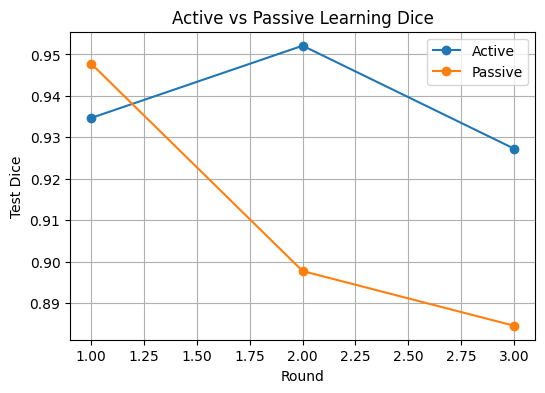

In [ ]:
# %% =========================================================
# cell 11. plot dice comparison
# purpose:
# compare active and passive learning test Dice across rounds
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(active_history_df["round"], active_history_df["test_dice"], marker="o", label="Active")
plt.plot(passive_history_df["round"], passive_history_df["test_dice"], marker="o", label="Passive")
plt.xlabel("Round")
plt.ylabel("Test Dice")
plt.title("Active vs Passive Learning Dice")
plt.legend()
plt.grid(True)
plt.show()

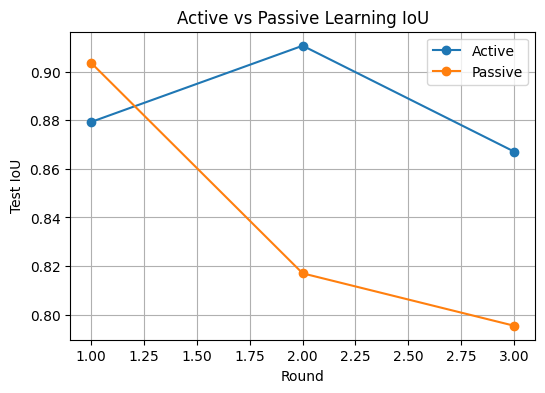

In [ ]:
# %% =========================================================
# cell 12. plot iou comparison
# purpose:
# compare active and passive learning test IoU across rounds
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(active_history_df["round"], active_history_df["test_iou"], marker="o", label="Active")
plt.plot(passive_history_df["round"], passive_history_df["test_iou"], marker="o", label="Passive")
plt.xlabel("Round")
plt.ylabel("Test IoU")
plt.title("Active vs Passive Learning IoU")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# %% =========================================================
# cell 13. compare active and passive predictions on fixed image ids
# purpose:
# show raw image, ground truth mask, active prediction, and passive
# prediction on the same exact test samples
# ============================================================

def compare_models_on_image_ids(active_model, passive_model, dataset, device, image_ids, threshold=0.5):
    active_model.eval()
    passive_model.eval()

    fig, axes = plt.subplots(len(image_ids), 4, figsize=(14, 4 * len(image_ids)))

    if len(image_ids) == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, image_id in enumerate(image_ids):
            matches = dataset.dataframe.index[dataset.dataframe["image_id"] == image_id].tolist()

            if len(matches) == 0:
                print(f"image_id not found: {image_id}")
                continue

            dataset_idx = matches[0]
            sample = dataset[dataset_idx]

            image_tensor = sample["image"].unsqueeze(0).to(device)
            raw_image = sample["image"].squeeze().cpu().numpy()
            true_mask = sample["mask"].squeeze().cpu().numpy()

            active_logits = active_model(image_tensor)
            active_pred = (torch.sigmoid(active_logits) > threshold).float().squeeze().cpu().numpy()

            passive_logits = passive_model(image_tensor)
            passive_pred = (torch.sigmoid(passive_logits) > threshold).float().squeeze().cpu().numpy()

            title_text = (
                f"Raw\n"
                f"idx={dataset_idx}\n"
                f"id={sample['image_id']}\n"
                f"source={sample['source']}"
            )

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].set_title(title_text)
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(true_mask, cmap="gray")
            axes[row_idx, 1].set_title("Ground Truth")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(active_pred, cmap="gray")
            axes[row_idx, 2].set_title("Active")
            axes[row_idx, 2].axis("off")

            axes[row_idx, 3].imshow(passive_pred, cmap="gray")
            axes[row_idx, 3].set_title("Passive")
            axes[row_idx, 3].axis("off")

    plt.tight_layout()
    plt.show()


          image_id   source
0   bbbc006_a04_s1  BBBC006
1   bbbc006_a13_s2  BBBC006
2   bbbc006_a14_s2  BBBC006
3   bbbc006_a16_s1  BBBC006
4   bbbc006_a17_s1  BBBC006
5   bbbc006_a23_s1  BBBC006
6   bbbc006_a24_s1  BBBC006
7   bbbc006_b05_s2  BBBC006
8   bbbc006_b10_s2  BBBC006
9   bbbc006_b12_s2  BBBC006
10  bbbc006_b13_s2  BBBC006
11  bbbc006_b17_s1  BBBC006
12  bbbc006_b17_s2  BBBC006
13  bbbc006_b21_s2  BBBC006
14  bbbc006_b24_s1  BBBC006
15  bbbc006_b24_s2  BBBC006
16  bbbc006_c02_s2  BBBC006
17  bbbc006_c04_s2  BBBC006
18  bbbc006_c05_s1  BBBC006
19  bbbc006_c10_s1  BBBC006

fixed_image_ids used for comparison:
['bbbc006_c10_s1', 'bbbc006_d16_s2', 'bbbc006_f07_s1', 'bbbc006_f17_s2', 'bbbc006_n21_s2']


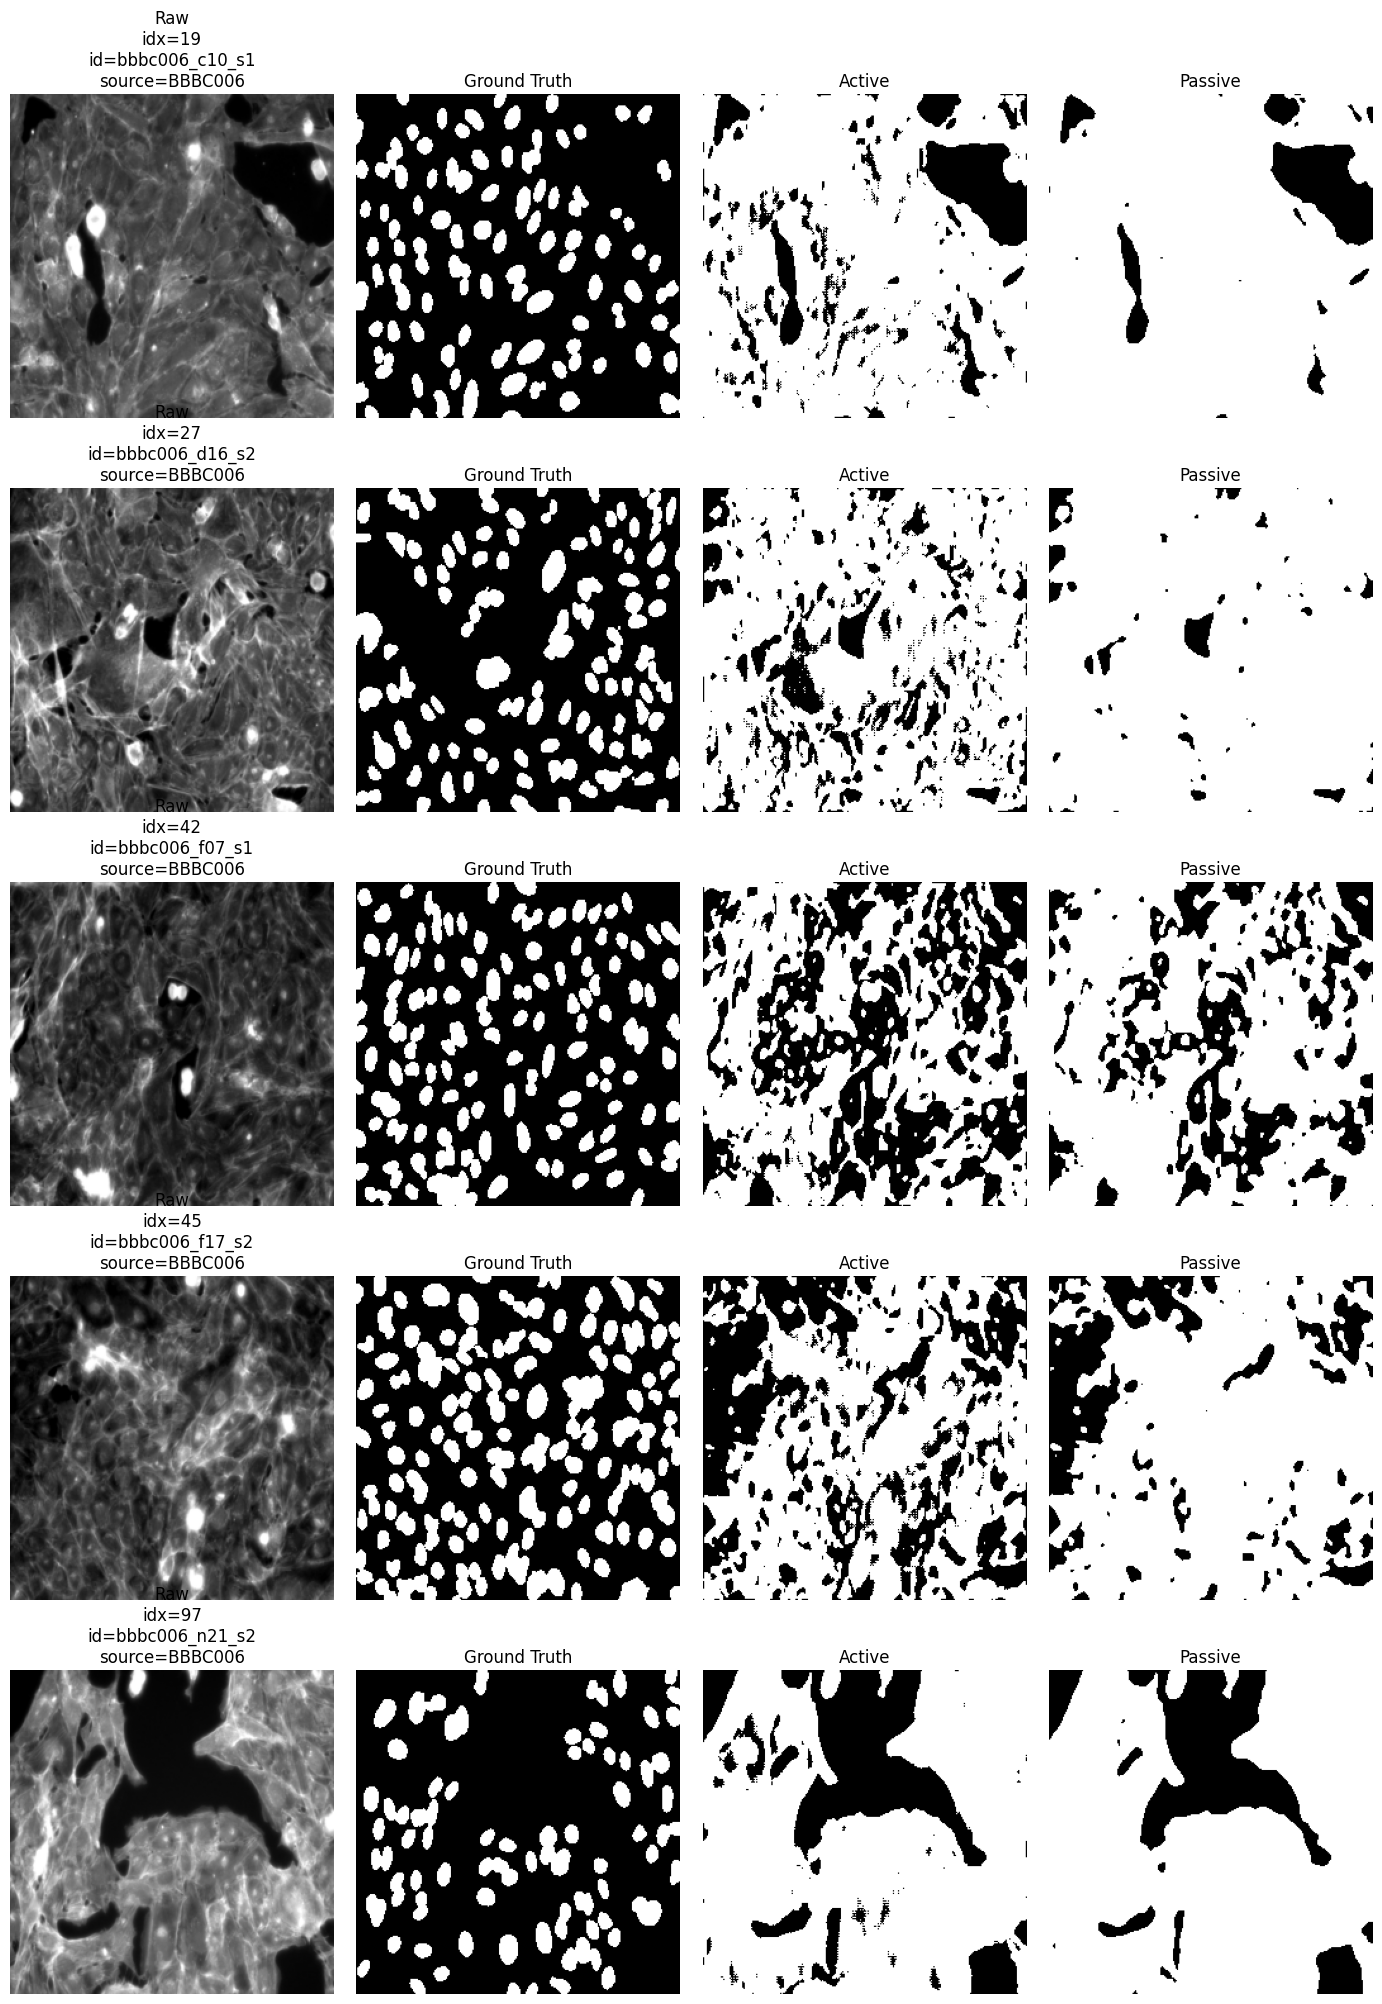

In [ ]:
# %% =========================================================
# cell 13b. compare on fixed image ids
# purpose:
# first inspect candidate ids, then set a fixed list to compare
# ============================================================

print(test_dataset.dataframe[["image_id", "source"]].head(20))

# replace these with image ids you want to show
fixed_image_ids = [
    test_dataset.dataframe.iloc[19]["image_id"],
    test_dataset.dataframe.iloc[27]["image_id"],
    test_dataset.dataframe.iloc[42]["image_id"],
    test_dataset.dataframe.iloc[45]["image_id"],
    test_dataset.dataframe.iloc[97]["image_id"],
]

print("\nfixed_image_ids used for comparison:")
print(fixed_image_ids)

compare_models_on_image_ids(
    active_model,
    passive_model,
    test_dataset,
    DEVICE,
    fixed_image_ids,
    threshold=0.5
)


In [ ]:
# %% =========================================================
# cell 14. compute per-image metrics and save to csv
# purpose:
# evaluate both models one image at a time and save per-image
# Dice and IoU for later analysis
# ============================================================

def compute_single_image_metrics(pred_mask, true_mask, smooth=1e-6):
    pred_flat = pred_mask.reshape(-1)
    true_flat = true_mask.reshape(-1)

    intersection = (pred_flat * true_flat).sum()
    union = pred_flat.sum() + true_flat.sum() - intersection

    dice = (2 * intersection + smooth) / (pred_flat.sum() + true_flat.sum() + smooth)
    iou = (intersection + smooth) / (union + smooth)

    return float(dice), float(iou)


def save_per_image_metrics(model, dataset, device, csv_path, threshold=0.5):
    model.eval()
    rows = []

    with torch.no_grad():
        for idx in range(len(dataset)):
            sample = dataset[idx]

            image_tensor = sample["image"].unsqueeze(0).to(device)
            true_mask = sample["mask"].squeeze().cpu().numpy()

            logits = model(image_tensor)
            probs = torch.sigmoid(logits)
            pred_mask = (probs > threshold).float().squeeze().cpu().numpy()

            dice, iou = compute_single_image_metrics(pred_mask, true_mask)

            rows.append({
                "dataset_index": int(sample["dataset_index"]),
                "image_id": sample["image_id"],
                "dice": dice,
                "iou": iou
            })

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(csv_path, index=False)

    print(f"saved per-image metrics to: {csv_path}")
    print(metrics_df.head())

    return metrics_df

In [ ]:
# %% =========================================================
# debug cell. inspect raw test image ids and paths
# purpose:
# check whether suspicious samples come from the same source but
# visually different image modalities
# ============================================================

interesting_ids = [
    "bbbc006_c10_s1",
    "bbbc006_d16_s2",
    "bbbc006_f07_s1",
    "bbbc006_f17_s2",
    "bbbc006_d21_s2"
]

print(
    test_dataset.dataframe[
        test_dataset.dataframe["image_id"].isin(interesting_ids)
    ][["image_id", "image_path", "mask_path", "source", "split"]]
)

          image_id                                         image_path  \
19  bbbc006_c10_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
27  bbbc006_d16_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   
42  bbbc006_f07_s1  /content/drive/MyDrive/ASR_Project/DATA/combin...   
45  bbbc006_f17_s2  /content/drive/MyDrive/ASR_Project/DATA/combin...   

                                            mask_path   source split  
19  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  test  
27  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  test  
42  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  test  
45  /content/drive/MyDrive/ASR_Project/DATA/combin...  BBBC006  test  


In [ ]:
# %% =========================================================
# cell 15. save active and passive per-image metrics
# purpose:
# save per-image Dice and IoU for both models on the test set
# ============================================================

active_test_metrics_df = save_per_image_metrics(
    model=active_model,
    dataset=test_dataset,
    device=DEVICE,
    csv_path="/content/drive/MyDrive/ASR_Project/active_test_per_image_metrics_newdata.csv",
    threshold=0.5
)

passive_test_metrics_df = save_per_image_metrics(
    model=passive_model,
    dataset=test_dataset,
    device=DEVICE,
    csv_path="/content/drive/MyDrive/ASR_Project/passive_test_per_image_metrics_newdata.csv",
    threshold=0.5
)

saved per-image metrics to: /content/drive/MyDrive/ASR_Project/active_test_per_image_metrics_newdata.csv
   dataset_index        image_id      dice       iou
0              0  bbbc006_a04_s1  0.933704  0.875652
1              1  bbbc006_a13_s2  0.943133  0.892386
2              2  bbbc006_a14_s2  0.958428  0.920175
3              3  bbbc006_a16_s1  0.381464  0.235685
4              4  bbbc006_a17_s1  0.944273  0.894429
saved per-image metrics to: /content/drive/MyDrive/ASR_Project/passive_test_per_image_metrics_newdata.csv
   dataset_index        image_id      dice       iou
0              0  bbbc006_a04_s1  0.887583  0.797886
1              1  bbbc006_a13_s2  0.900175  0.818471
2              2  bbbc006_a14_s2  0.913957  0.841548
3              3  bbbc006_a16_s1  0.364623  0.222960
4              4  bbbc006_a17_s1  0.905210  0.826835


In [ ]:
# %% =========================================================
# cell 16. merged per-image comparison and plotting
# purpose:
# merge active and passive per-image metrics, save the table,
# and create per-image IoU and Dice line plots
# ============================================================

comparison_per_image_df = active_test_metrics_df.merge(
    passive_test_metrics_df,
    on=["dataset_index", "image_id", "source"],
    suffixes=("_active", "_passive")
)

comparison_per_image_df["iou_gain_active_minus_passive"] = (
    comparison_per_image_df["iou_active"] - comparison_per_image_df["iou_passive"]
)
comparison_per_image_df["dice_gain_active_minus_passive"] = (
    comparison_per_image_df["dice_active"] - comparison_per_image_df["dice_passive"]
)

comparison_per_image_df.to_csv(
    "/content/drive/MyDrive/ASR_Project/active_vs_passive_test_per_image_metrics_newdata.csv",
    index=False
)

print(comparison_per_image_df.head())

plt.figure(figsize=(10, 5))
plt.plot(
    comparison_per_image_df["dataset_index"],
    comparison_per_image_df["iou_passive"],
    label="Passive vs Ground Truth"
)
plt.plot(
    comparison_per_image_df["dataset_index"],
    comparison_per_image_df["iou_active"],
    label="Active vs Ground Truth"
)
plt.xlabel("Image ID")
plt.ylabel("Intersection of Union (IoU)")
plt.title("Intersection of Union Comparison between Passive and Active Learning Algorithms")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(
    comparison_per_image_df["dataset_index"],
    comparison_per_image_df["dice_passive"],
    label="Passive vs Ground Truth"
)
plt.plot(
    comparison_per_image_df["dataset_index"],
    comparison_per_image_df["dice_active"],
    label="Active vs Ground Truth"
)
plt.xlabel("Image ID")
plt.ylabel("Dice")
plt.title("Dice Comparison between Passive and Active Learning Algorithms")
plt.legend()
plt.grid(True)
plt.show()

print("\nworst active IoU examples:")
print(
    comparison_per_image_df[
        ["dataset_index", "image_id", "source", "iou_active", "iou_passive", "iou_gain_active_minus_passive"]
    ].sort_values("iou_active").head(10)
)

print("\nbiggest active IoU gains over passive:")
print(
    comparison_per_image_df[
        ["dataset_index", "image_id", "source", "iou_active", "iou_passive", "iou_gain_active_minus_passive"]
    ].sort_values("iou_gain_active_minus_passive", ascending=False).head(10)
)


KeyError: 'source'